# Calculating Water Change at the Ethnologue Polygon Level

> GEE download step lives in [`waterchange_download.ipynb`](waterchange_download.ipynb). 
This notebook assumes the exported rasters are already on disk.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties

import mapclassify

from rapidfuzz import process, fuzz

from shapely.geometry import Point

import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterstats import zonal_stats
from glob import glob
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling

In [2]:
# Set base project path
base_path = Path("C:/Users/juami/Dropbox/RAships/2-Folklore-Nathan-Project/EA-Maps-Nathan-project/Measures_work")

# Set file paths
poscol_path = base_path / "data" / "raw" / "ethnologue" / "ancestral_characteristics_database_language_level" / "Ethnologue_16_shapefile" / "langa_no_overlap_biggest_clean.shp"

data_path = base_path / "data" / "interim"
maps_path = base_path / "maps" / "raw"
water_path = maps_path / "Water_surface" 

In [3]:
# Read the shapefiles and CSV files
ethnologue = gpd.read_file(poscol_path)

# Keep only relevant columns
ethnologue = ethnologue[["ID", "geometry"]]

print(f"Number of features: {len(ethnologue)}") 

Number of features: 7087


In [4]:
# --- HydroLakes: define a mask that zeros out non-natural lakes ---
# Lake_type = 2 (reservoirs) and 3 (lake-control / regulated outflow) are
# excluded from the "_excl_res" measures. Natural lakes (Lake_type=1) and
# everything else (rivers, coastline, ocean) keep their original values.
from rasterio.features import rasterize

hydrolakes_path = maps_path / "Water_surface" / "hydrolakes" / "hydrolakes_v10_all.shp"
lakes = gpd.read_file(hydrolakes_path)[["Lake_type", "geometry"]]
lakes_nonnat = lakes[lakes["Lake_type"].isin([2, 3])].to_crs("EPSG:4326")

print(f"Non-natural lakes (Lake_type=2,3): {len(lakes_nonnat):,} polygons used as exclusion mask")


def zonal_excl_res(water_arr, out_trans, ethnologue, out_prefix, stat):
    # water_arr: 2D numpy array (binary 0/1 if stat=='sum'; continuous if stat=='mean')
    # For 'sum'  : pixels inside non-natural lakes are set to 0 before zonal sum.
    # For 'mean' : pixels inside non-natural lakes are set to NaN so zonal mean ignores them.
    # Output column suffix: '_excl_res'.
    shape = water_arr.shape

    non_rast = rasterize(
        [(g, 1) for g in lakes_nonnat.geometry],
        out_shape=shape, transform=out_trans, fill=0, dtype='uint8',
    )

    if stat == "sum":
        masked = (water_arr * (1 - non_rast)).astype('uint8')
        dtype, nodata_kw, zs_kw = 'uint8', {}, {}
    elif stat == "mean":
        masked = np.where(non_rast == 1, np.nan, water_arr).astype('float32')
        dtype, nodata_kw, zs_kw = 'float32', {'nodata': np.nan}, {'nodata': np.nan}
    else:
        raise ValueError(f"stat must be 'sum' or 'mean', got {stat!r}")

    with MemoryFile() as memfile:
        with memfile.open(
            driver='GTiff', height=masked.shape[0], width=masked.shape[1],
            count=1, dtype=dtype, transform=out_trans, crs='EPSG:4326', **nodata_kw
        ) as dataset:
            dataset.write(masked, 1)
        stats = zonal_stats(
            ethnologue, memfile.name, stats=[stat], geojson_out=True, **zs_kw
        )

    if stat == "sum":
        ethnologue[f'{out_prefix}_pixels_excl_res'] = [f['properties']['sum'] for f in stats]
        ethnologue[f'{out_prefix}_km2_excl_res']    = ethnologue[f'{out_prefix}_pixels_excl_res'] * 0.01
    else:
        ethnologue[f'{out_prefix}_excl_res'] = [f['properties']['mean'] for f in stats]

    return ethnologue


Non-natural lakes (Lake_type=2,3): 6,796 polygons used as exclusion mask


In [5]:
# List all the raster files 
raster_files = glob(str(water_path / "perm_water" / "*.tif"))

print("Found raster files:", raster_files)

# Read in all the rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

from rasterio.merge import merge

# Set a coarser resolution
mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),  # Approx ~1km resolution (in degrees)
    resampling=Resampling.average  # Can also try Resampling.nearest
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water\\perm_water_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water\\perm_water_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water\\perm_water_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water\\perm_water_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water\\perm_water_100m_30m-0000000000-0000262144.tif', 'C:\\Users\\juami\\Dropbox\\RAship

In [6]:
# Check CRS of each input raster
for i, src in enumerate(src_files_to_mosaic):
    print(f"Raster {i} CRS:", src.crs)

ethnologue = ethnologue.to_crs(src_files_to_mosaic[0].crs)

Raster 0 CRS: EPSG:4326
Raster 1 CRS: EPSG:4326
Raster 2 CRS: EPSG:4326
Raster 3 CRS: EPSG:4326
Raster 4 CRS: EPSG:4326
Raster 5 CRS: EPSG:4326
Raster 6 CRS: EPSG:4326
Raster 7 CRS: EPSG:4326
Raster 8 CRS: EPSG:4326
Raster 9 CRS: EPSG:4326
Raster 10 CRS: EPSG:4326
Raster 11 CRS: EPSG:4326
Raster 12 CRS: EPSG:4326
Raster 13 CRS: EPSG:4326
Raster 14 CRS: EPSG:4326
Raster 15 CRS: EPSG:4326
Raster 16 CRS: EPSG:4326
Raster 17 CRS: EPSG:4326
Raster 18 CRS: EPSG:4326
Raster 19 CRS: EPSG:4326
Raster 20 CRS: EPSG:4326


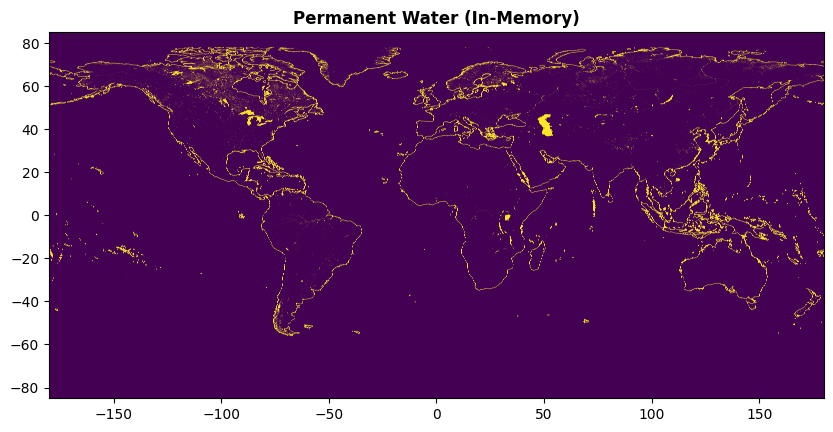

In [7]:
# Show the first band of the mosaic directly
fig, ax = plt.subplots(figsize=(10, 10))
show(mosaic, transform=out_trans, ax=ax, title="Permanent Water (In-Memory)")
plt.show()

In [8]:
# Threshold: create binary mask from mosaic
binary_mask = (mosaic[0] > 0).astype(np.uint8)  # 1 = perm water, 0 = non-water

# Save binary mask to a temporary raster file (needed for zonal_stats)
with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=binary_mask.shape[0],
        width=binary_mask.shape[1],
        count=1,
        dtype='uint8',
        transform=out_trans,
        crs='EPSG:4326' 
    ) as dataset:
        dataset.write(binary_mask, 1)

    # Compute zonal statistics using sum (since forest = 1, sum = count of pixels)
    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['sum'],
        geojson_out=True
    )

# Attach results to GeoDataFrame
ethnologue['permwater_pixels'] = [f['properties']['sum'] for f in stats]

# Calculate area in km² (each pixel = 0.01 km² at 100m resolution)
ethnologue['permwater_km2'] = ethnologue['permwater_pixels'] * 0.01

# View results
ethnologue[['ID', 'permwater_pixels', 'permwater_km2']].head()

C:\Users\juami\anaconda3\envs\geo_clean\Lib\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


,ID,permwater_pixels,permwater_km2
0,RUS-RUS,186735.0,1867.35
1,ENG-USA,81677.0,816.77
2,POR-BRA,55295.0,552.95
3,ENG-AUS,10551.0,105.51
4,CMN-CHN,16988.0,169.88


In [9]:
# Permanent water excluding non-natural lakes (Lake_type 2 or 3)
ethnologue = zonal_excl_res(binary_mask, out_trans, ethnologue, 'permwater', 'sum')
ethnologue[['ID', 'permwater_km2', 'permwater_km2_excl_res']].head()


,ID,permwater_km2,permwater_km2_excl_res
0,RUS-RUS,1867.35,1435.38
1,ENG-USA,816.77,545.74
2,POR-BRA,552.95,468.66
3,ENG-AUS,105.51,91.74
4,CMN-CHN,169.88,141.19


In [10]:
# List all the raster files 
raster_files = glob(str(water_path / "loss_water" / "*.tif"))

print("Found raster files:", raster_files)

# Read in all the rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

from rasterio.merge import merge

# Set a coarser resolution
mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),  # Approx ~1km resolution (in degrees)
    resampling=Resampling.average  # Can also try Resampling.nearest
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\loss_water\\loss_water_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\loss_water\\loss_water_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\loss_water\\loss_water_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\loss_water\\loss_water_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\loss_water\\loss_water_100m_30m-0000000000-0000262144.tif', 'C:\\Users\\juami\\Dropbox\\RAship

In [11]:
# Threshold: create binary mask from mosaic
binary_mask = (mosaic[0] > 0).astype(np.uint8)  # 1 = perm water, 0 = non-water

# Save binary mask to a temporary raster file (needed for zonal_stats)
with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=binary_mask.shape[0],
        width=binary_mask.shape[1],
        count=1,
        dtype='uint8',
        transform=out_trans,
        crs='EPSG:4326' 
    ) as dataset:
        dataset.write(binary_mask, 1)

    # Compute zonal statistics using sum (since forest = 1, sum = count of pixels)
    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['sum'],
        geojson_out=True
    )

# Attach results to GeoDataFrame
ethnologue['losswater_pixels'] = [f['properties']['sum'] for f in stats]

# Calculate area in km² (each pixel = 0.01 km² at 100m resolution)
ethnologue['losswater_km2'] = ethnologue['losswater_pixels'] * 0.01

# View results
ethnologue[['ID', 'losswater_km2', 'losswater_pixels']].head()

,ID,losswater_km2,losswater_pixels
0,RUS-RUS,11.44,1144.0
1,ENG-USA,29.60,2960.0
2,POR-BRA,8.76,876.0
3,ENG-AUS,3.93,393.0
4,CMN-CHN,5.18,518.0


In [12]:
# Loss of permanent water excluding non-natural lakes
ethnologue = zonal_excl_res(binary_mask, out_trans, ethnologue, 'losswater', 'sum')
ethnologue[['ID', 'losswater_km2', 'losswater_km2_excl_res']].head()


,ID,losswater_km2,losswater_km2_excl_res
0,RUS-RUS,11.44,11.32
1,ENG-USA,29.60,25.91
2,POR-BRA,8.76,8.36
3,ENG-AUS,3.93,3.08
4,CMN-CHN,5.18,5.15


In [13]:
# List all the raster files - permanent in 1984-1999, became seasonal in 2000-2021 (transition == 8)
raster_files = glob(str(water_path / "transition_water" / "*.tif"))

print("Found raster files:", raster_files)

# Read in all the rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

# Set a coarser resolution
mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),  # Approx ~1km resolution (in degrees)
    resampling=Resampling.average
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\transition_water\\permseasonal_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\transition_water\\permseasonal_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\transition_water\\permseasonal_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\transition_water\\permseasonal_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\transition_water\\permseasonal_100m_30m-0000000000-0000262144.

In [14]:
# Threshold: create binary mask from mosaic
binary_mask = (mosaic[0] > 0).astype(np.uint8)  # 1 = perm-to-seasonal, 0 = otherwise

with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=binary_mask.shape[0],
        width=binary_mask.shape[1],
        count=1,
        dtype='uint8',
        transform=out_trans,
        crs='EPSG:4326'
    ) as dataset:
        dataset.write(binary_mask, 1)

    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['sum'],
        geojson_out=True
    )

ethnologue['permseasonal_pixels'] = [f['properties']['sum'] for f in stats]
ethnologue['permseasonal_km2']    = ethnologue['permseasonal_pixels'] * 0.01

# Total permanent water in the 1984-1999 baseline epoch:
#   transition==1 (still permanent) + transition==3 (lost permanent) + transition==8 (became seasonal)
ethnologue['permwater_baseline_km2'] = (
    ethnologue['permwater_km2']
    + ethnologue['losswater_km2']
    + ethnologue['permseasonal_km2']
)

ethnologue[['ID', 'permseasonal_km2', 'permwater_baseline_km2']].head()

,ID,permseasonal_km2,permwater_baseline_km2
0,RUS-RUS,18.91,1897.70
1,ENG-USA,11.76,858.13
2,POR-BRA,2.78,564.49
3,ENG-AUS,2.73,112.17
4,CMN-CHN,2.41,177.47


In [15]:
# Permanent->seasonal transition excluding non-natural lakes,
# plus the corresponding 1984-1999 baseline:
#   permwater_baseline_km2_excl_res = permwater_km2_excl_res
#                                   + losswater_km2_excl_res
#                                   + permseasonal_km2_excl_res
ethnologue = zonal_excl_res(binary_mask, out_trans, ethnologue, 'permseasonal', 'sum')

ethnologue['permwater_baseline_km2_excl_res'] = (
    ethnologue['permwater_km2_excl_res']
    + ethnologue['losswater_km2_excl_res']
    + ethnologue['permseasonal_km2_excl_res']
)

ethnologue[['ID', 'permwater_baseline_km2', 'permwater_baseline_km2_excl_res']].head()


,ID,permwater_baseline_km2,permwater_baseline_km2_excl_res
0,RUS-RUS,1897.70,1465.31
1,ENG-USA,858.13,580.68
2,POR-BRA,564.49,479.09
3,ENG-AUS,112.17,97.34
4,CMN-CHN,177.47,148.48


In [16]:
# List all the raster files 
raster_files = glob(str(water_path / "change_water" / "*.tif"))

print("Found raster files:", raster_files)

# Read in all the rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

from rasterio.merge import merge

# Set a coarser resolution
mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),  # Approx ~1km resolution (in degrees)
    resampling=Resampling.average  # Can also try Resampling.nearest
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water\\change_water_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water\\change_water_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water\\change_water_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water\\change_water_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water\\change_water_100m_30m-0000000000-0000262144.tif', 'C:\\Users\\ju

In [17]:
# Save continuous raster to a temporary raster file (needed for zonal_stats)
with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=mosaic.shape[1],  # Shape is (bands, height, width)
        width=mosaic.shape[2],
        count=1,
        dtype='float32',
        transform=out_trans,
        crs='EPSG:4326' 
    ) as dataset:
        dataset.write(mosaic[0], 1)  # Write first band only

    # Compute zonal statistics using mean for continuous water change values
    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['mean'],
        geojson_out=True
    )

# Attach results to GeoDataFrame
ethnologue['changewater'] = [f['properties']['mean'] for f in stats]

# View results
ethnologue[['ID', 'changewater']].head()

,ID,changewater
0,RUS-RUS,-0.326560
1,ENG-USA,0.318669
2,POR-BRA,0.234857
3,ENG-AUS,0.281524
4,CMN-CHN,0.699520


In [18]:
# Surface water change (change_norm band) excluding non-natural lakes
ethnologue = zonal_excl_res(mosaic[0], out_trans, ethnologue, 'changewater', 'mean')
ethnologue[['ID', 'changewater', 'changewater_excl_res']].head()


,ID,changewater,changewater_excl_res
0,RUS-RUS,-0.326560,-0.321612
1,ENG-USA,0.318669,0.323075
2,POR-BRA,0.234857,0.209506
3,ENG-AUS,0.281524,0.286161
4,CMN-CHN,0.699520,0.692288


In [19]:
# --- changewater_abs (JRC change_abs band, absolute change in km^2-equivalent) ---
# Parallel to the change_norm-based `changewater` computed above. Requires
# `change_water_abs/*.tif` rasters from the download notebook (the export cell
# uses fileNamePrefix='change_water_abs_100m_30m' — once GEE finishes, place
# the .tif files under Water_surface/change_water_abs/).
raster_files = glob(str(water_path / "change_water_abs" / "*.tif"))

print("Found raster files:", raster_files)

# Read in all the rasters
src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

# Set a coarser resolution
mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),
    resampling=Resampling.average
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water_abs\\change_water_abs_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water_abs\\change_water_abs_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water_abs\\change_water_abs_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water_abs\\change_water_abs_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\change_water_abs\\change_water_abs_100m_30m-00

In [20]:
# Save continuous raster to a temporary raster file (needed for zonal_stats)
with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=mosaic.shape[1],
        width=mosaic.shape[2],
        count=1,
        dtype='float32',
        transform=out_trans,
        crs='EPSG:4326'
    ) as dataset:
        dataset.write(mosaic[0], 1)

    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['mean'],
        geojson_out=True
    )

ethnologue['changewater_abs'] = [f['properties']['mean'] for f in stats]

ethnologue[['ID', 'changewater', 'changewater_abs']].head()

,ID,changewater,changewater_abs
0,RUS-RUS,-0.326560,-0.857195
1,ENG-USA,0.318669,-0.045558
2,POR-BRA,0.234857,0.031589
3,ENG-AUS,0.281524,-0.108591
4,CMN-CHN,0.699520,-0.157358


In [21]:
# Surface water change (change_abs band) excluding non-natural lakes
ethnologue = zonal_excl_res(mosaic[0], out_trans, ethnologue, 'changewater_abs', 'mean')
ethnologue[['ID', 'changewater_abs', 'changewater_abs_excl_res']].head()


,ID,changewater_abs,changewater_abs_excl_res
0,RUS-RUS,-0.857195,-0.851696
1,ENG-USA,-0.045558,-0.039854
2,POR-BRA,0.031589,0.005438
3,ENG-AUS,-0.108591,-0.103763
4,CMN-CHN,-0.157358,-0.157305


In [22]:
# --- Permanent water in year 2000 (JRC YearlyHistory, waterClass == 3) ---
raster_files = glob(str(water_path / "perm_water_2000" / "*.tif"))

print("Found raster files:", raster_files)

src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),
    resampling=Resampling.average
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water_2000\\permwater_yh2000_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water_2000\\permwater_yh2000_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water_2000\\permwater_yh2000_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water_2000\\permwater_yh2000_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\perm_water_2000\\permwater_yh2000_100m_30m-0000000

In [23]:
# Threshold: binary mask (1 = permanent water in 2000, 0 = otherwise)
binary_mask = (mosaic[0] > 0).astype(np.uint8)

with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=binary_mask.shape[0],
        width=binary_mask.shape[1],
        count=1,
        dtype='uint8',
        transform=out_trans,
        crs='EPSG:4326'
    ) as dataset:
        dataset.write(binary_mask, 1)

    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['sum'],
        geojson_out=True
    )

ethnologue['permwater_2000_pixels'] = [f['properties']['sum'] for f in stats]
ethnologue['permwater_2000_km2']    = ethnologue['permwater_2000_pixels'] * 0.01

ethnologue[['ID', 'permwater_2000_pixels', 'permwater_2000_km2']].head()

,ID,permwater_2000_pixels,permwater_2000_km2
0,RUS-RUS,203066.0,2030.66
1,ENG-USA,90516.0,905.16
2,POR-BRA,65010.0,650.10
3,ENG-AUS,12043.0,120.43
4,CMN-CHN,19822.0,198.22


In [24]:
# Permanent water in 2000 excluding non-natural lakes
ethnologue = zonal_excl_res(binary_mask, out_trans, ethnologue, 'permwater_2000', 'sum')
ethnologue[['ID', 'permwater_2000_km2', 'permwater_2000_km2_excl_res']].head()


,ID,permwater_2000_km2,permwater_2000_km2_excl_res
0,RUS-RUS,2030.66,1587.97
1,ENG-USA,905.16,615.98
2,POR-BRA,650.10,523.97
3,ENG-AUS,120.43,101.98
4,CMN-CHN,198.22,170.48


In [25]:
# --- Seasonal water in year 2000 (JRC YearlyHistory, waterClass == 2) ---
raster_files = glob(str(water_path / "seasonal_water_2000" / "*.tif"))

print("Found raster files:", raster_files)

src_files_to_mosaic = [rasterio.open(fp) for fp in raster_files]

mosaic, out_trans = merge(
    src_files_to_mosaic,
    res=(0.01, 0.01),
    resampling=Resampling.average
)

Found raster files: ['C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\seasonal_water_2000\\seasonalwater_yh2000_100m_30m-0000000000-0000000000.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\seasonal_water_2000\\seasonalwater_yh2000_100m_30m-0000000000-0000065536.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\seasonal_water_2000\\seasonalwater_yh2000_100m_30m-0000000000-0000131072.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\seasonal_water_2000\\seasonalwater_yh2000_100m_30m-0000000000-0000196608.tif', 'C:\\Users\\juami\\Dropbox\\RAships\\2-Folklore-Nathan-Project\\EA-Maps-Nathan-project\\Measures_work\\maps\\raw\\Water_surface\\seasonal_water_200

In [26]:
# Threshold: binary mask (1 = seasonal water in 2000, 0 = otherwise)
binary_mask = (mosaic[0] > 0).astype(np.uint8)

with MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=binary_mask.shape[0],
        width=binary_mask.shape[1],
        count=1,
        dtype='uint8',
        transform=out_trans,
        crs='EPSG:4326'
    ) as dataset:
        dataset.write(binary_mask, 1)

    stats = zonal_stats(
        ethnologue,
        memfile.name,
        stats=['sum'],
        geojson_out=True
    )

ethnologue['seasonalwater_2000_pixels'] = [f['properties']['sum'] for f in stats]
ethnologue['seasonalwater_2000_km2']    = ethnologue['seasonalwater_2000_pixels'] * 0.01

ethnologue[['ID', 'seasonalwater_2000_pixels', 'seasonalwater_2000_km2']].head()

,ID,seasonalwater_2000_pixels,seasonalwater_2000_km2
0,RUS-RUS,44659.0,446.59
1,ENG-USA,10240.0,102.40
2,POR-BRA,12391.0,123.91
3,ENG-AUS,25452.0,254.52
4,CMN-CHN,15013.0,150.13


In [27]:
# Seasonal water in 2000 excluding non-natural lakes
ethnologue = zonal_excl_res(binary_mask, out_trans, ethnologue, 'seasonalwater_2000', 'sum')
ethnologue[['ID', 'seasonalwater_2000_km2', 'seasonalwater_2000_km2_excl_res']].head()


,ID,seasonalwater_2000_km2,seasonalwater_2000_km2_excl_res
0,RUS-RUS,446.59,444.13
1,ENG-USA,102.40,96.04
2,POR-BRA,123.91,119.78
3,ENG-AUS,254.52,254.11
4,CMN-CHN,150.13,144.19


In [28]:
df_ethnologue = ethnologue[['ID',
                            'permwater_pixels', 'permwater_km2',
                            'permwater_km2_excl_res',
                            'losswater_pixels', 'losswater_km2',
                            'losswater_km2_excl_res',
                            'permseasonal_pixels', 'permseasonal_km2',
                            'permseasonal_km2_excl_res',
                            'permwater_baseline_km2',
                            'permwater_baseline_km2_excl_res',
                            'permwater_2000_pixels', 'permwater_2000_km2',
                            'permwater_2000_km2_excl_res',
                            'seasonalwater_2000_pixels', 'seasonalwater_2000_km2',
                            'seasonalwater_2000_km2_excl_res',
                            'changewater', 'changewater_excl_res',
                            'changewater_abs', 'changewater_abs_excl_res']]

df_ethnologue.head()


,ID,permwater_pixels,permwater_km2,permwater_km2_excl_res,losswater_pixels,losswater_km2,losswater_km2_excl_res,permseasonal_pixels,permseasonal_km2,permseasonal_km2_excl_res,...,permwater_2000_pixels,permwater_2000_km2,permwater_2000_km2_excl_res,seasonalwater_2000_pixels,seasonalwater_2000_km2,seasonalwater_2000_km2_excl_res,changewater,changewater_excl_res,changewater_abs,changewater_abs_excl_res
0,RUS-RUS,186735.0,1867.35,1435.38,1144.0,11.44,11.32,1891.0,18.91,18.61,...,203066.0,2030.66,1587.97,44659.0,446.59,444.13,-0.326560,-0.321612,-0.857195,-0.851696
1,ENG-USA,81677.0,816.77,545.74,2960.0,29.60,25.91,1176.0,11.76,9.03,...,90516.0,905.16,615.98,10240.0,102.40,96.04,0.318669,0.323075,-0.045558,-0.039854
2,POR-BRA,55295.0,552.95,468.66,876.0,8.76,8.36,278.0,2.78,2.07,...,65010.0,650.10,523.97,12391.0,123.91,119.78,0.234857,0.209506,0.031589,0.005438
3,ENG-AUS,10551.0,105.51,91.74,393.0,3.93,3.08,273.0,2.73,2.52,...,12043.0,120.43,101.98,25452.0,254.52,254.11,0.281524,0.286161,-0.108591,-0.103763
4,CMN-CHN,16988.0,169.88,141.19,518.0,5.18,5.15,241.0,2.41,2.14,...,19822.0,198.22,170.48,15013.0,150.13,144.19,0.699520,0.692288,-0.157358,-0.157305


In [29]:
len(df_ethnologue)

7087

In [30]:
# Export to CSV
df_ethnologue.to_csv(water_path / "perm_loss_water.csv", index=False)

print(f"Exported df_ethnologue.csv")

Exported df_ethnologue.csv
